In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [5]:
df['species'] = le.fit_transform(df['species'])

In [6]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
106,4.9,2.5,4.5,1.7,2
84,5.4,3.0,4.5,1.5,1
31,5.4,3.4,1.5,0.4,0
66,5.6,3.0,4.5,1.5,1
133,6.3,2.8,5.1,1.5,2


In [7]:
df = df[df['species'] != 0][['sepal_width', 'petal_length', 'species']]

In [8]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

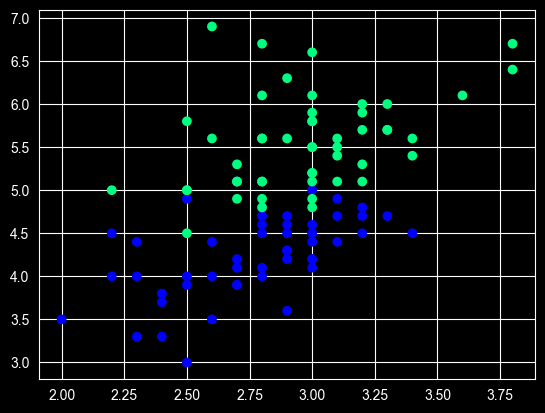

In [10]:
plt.scatter(df['sepal_width'], df['petal_length'], c = df['species'], cmap = 'winter')

In [11]:
# taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [12]:
df_train

,sepal_width,petal_length,species
84,3.0,4.5,1
112,3.0,5.5,2
117,3.8,6.7,2
68,2.2,4.5,1
75,3.0,4.4,1
119,2.2,5.0,2
51,3.2,4.5,1
99,2.8,4.1,1
53,2.3,4.0,1
147,3.0,5.2,2


In [13]:
df_val

,sepal_width,petal_length,species
61,3.0,4.2,1
50,3.2,4.7,1
92,2.6,4.0,1
128,2.8,5.6,2
81,2.4,3.7,1


In [14]:
df_test

,sepal_width,petal_length,species
149,3.0,5.1,2
94,2.7,4.2,1
135,3.0,6.1,2
145,3.0,5.2,2
109,3.6,6.1,2


In [15]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

In [16]:
X_test

array([[3. , 4.2],
       [3.2, 4.7],
       [2.6, 4. ],
       [2.8, 5.6],
       [2.4, 3.7]])

In [17]:
y_test

array([1, 1, 1, 2, 1])

Case 1 - Bagging

In [18]:
# Data for tree 1
df_bag = df_train.sample(8, replace = True)
X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]
df_bag

,sepal_width,petal_length,species
75,3.0,4.4,1
84,3.0,4.5,1
147,3.0,5.2,2
51,3.2,4.5,1
53,2.3,4.0,1
84,3.0,4.5,1
51,3.2,4.5,1
53,2.3,4.0,1


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [20]:
dt_bag1 = DecisionTreeClassifier()

In [21]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

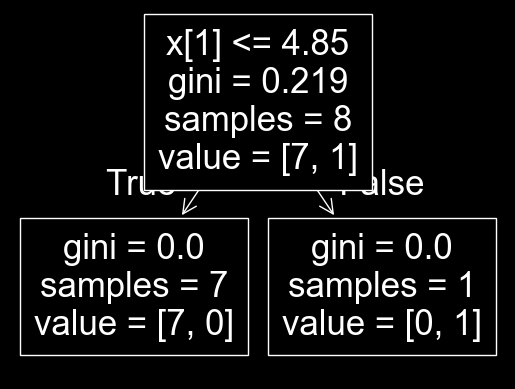

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


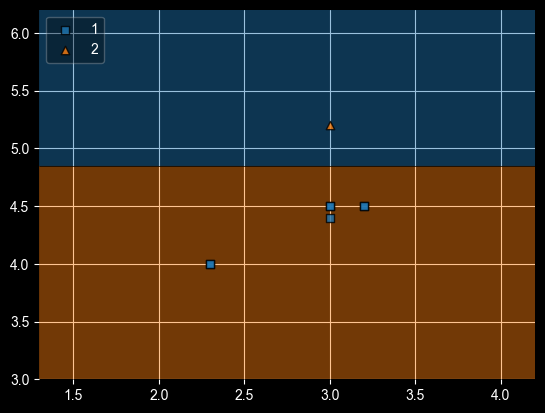

In [22]:
evaluate(dt_bag1, X, y)

In [23]:
# Data for tree 1
df_bag = df_train.sample(8, replace = True)
X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]
df_bag

,sepal_width,petal_length,species
53,2.3,4.0,1
117,3.8,6.7,2
75,3.0,4.4,1
99,2.8,4.1,1
53,2.3,4.0,1
53,2.3,4.0,1
117,3.8,6.7,2
99,2.8,4.1,1


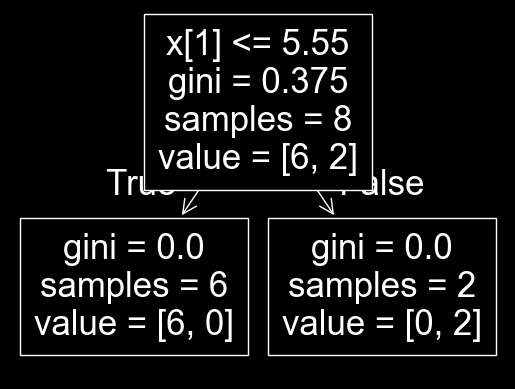

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


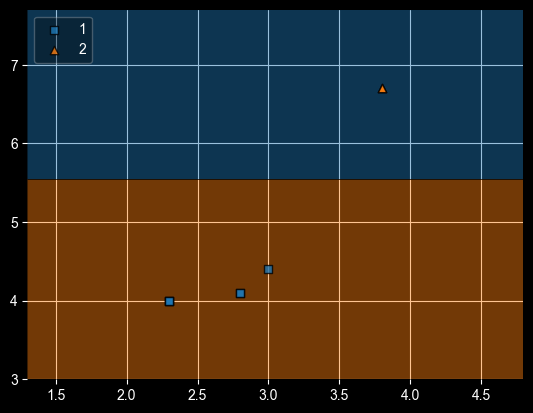

In [24]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

In [25]:
# Data for tree 1
df_bag = df_train.sample(8, replace = True)
X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]
df_bag

,sepal_width,petal_length,species
51,3.2,4.5,1
99,2.8,4.1,1
99,2.8,4.1,1
99,2.8,4.1,1
84,3.0,4.5,1
147,3.0,5.2,2
99,2.8,4.1,1
99,2.8,4.1,1


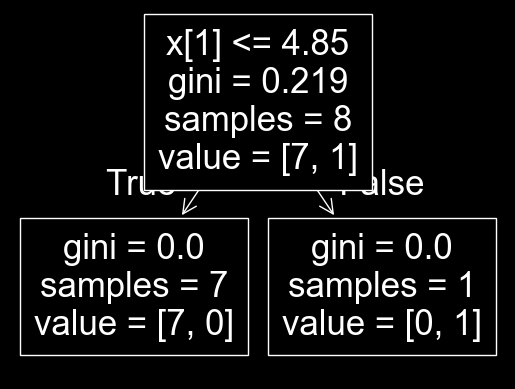

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


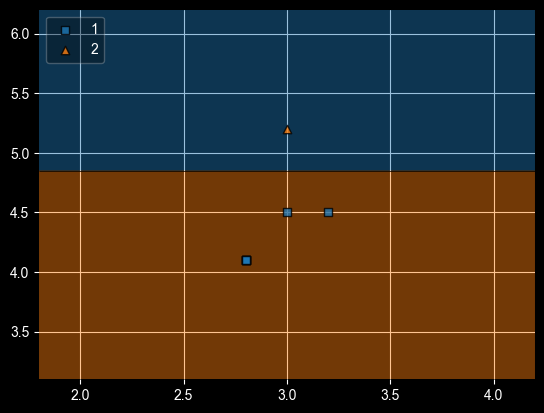

In [26]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

Predict

In [27]:
df_test

,sepal_width,petal_length,species
149,3.0,5.1,2
94,2.7,4.2,1
135,3.0,6.1,2
145,3.0,5.2,2
109,3.6,6.1,2


In [28]:
print("Predictor 1 : ", dt_bag1.predict(np.array([2.5, 5.0]).reshape(1, 2)))
print("Predictor 2 : ", dt_bag2.predict(np.array([2.5, 5.0]).reshape(1, 2)))
print("Predictor 3 : ", dt_bag3.predict(np.array([2.5, 5.0]).reshape(1, 2)))

Predictor 1 :  [2]
Predictor 2 :  [1]
Predictor 3 :  [2]


C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting

In [29]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
84,3.0,4.5,1
112,3.0,5.5,2
117,3.8,6.7,2
68,2.2,4.5,1
75,3.0,4.4,1
119,2.2,5.0,2
51,3.2,4.5,1
99,2.8,4.1,1
53,2.3,4.0,1
147,3.0,5.2,2


In [30]:
df_train.sample(8)

,sepal_width,petal_length,species
53,2.3,4.0,1
51,3.2,4.5,1
112,3.0,5.5,2
99,2.8,4.1,1
75,3.0,4.4,1
84,3.0,4.5,1
68,2.2,4.5,1
117,3.8,6.7,2


Random Subspaces

In [31]:
# columns sampling
df1 = pd.read_csv("iris.csv")
df1 = df1.sample(10)

In [32]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
69,5.6,2.5,3.9,1.1,Iris-versicolor
140,6.7,3.1,5.6,2.4,Iris-virginica
16,5.4,3.9,1.3,0.4,Iris-setosa
11,4.8,3.4,1.6,0.2,Iris-setosa
21,5.1,3.7,1.5,0.4,Iris-setosa
118,7.7,2.6,6.9,2.3,Iris-virginica
80,5.5,2.4,3.8,1.1,Iris-versicolor
82,5.8,2.7,3.9,1.2,Iris-versicolor
139,6.9,3.1,5.4,2.1,Iris-virginica
113,5.7,2.5,5.0,2.0,Iris-virginica


In [33]:
df1.sample(2, replace = True, axis = 1)

,species,petal_length
69,Iris-versicolor,3.9
140,Iris-virginica,5.6
16,Iris-setosa,1.3
11,Iris-setosa,1.6
21,Iris-setosa,1.5
118,Iris-virginica,6.9
80,Iris-versicolor,3.8
82,Iris-versicolor,3.9
139,Iris-virginica,5.4
113,Iris-virginica,5.0


Random Patches

In [34]:
# Both row sampling and column sampling
df1

,sepal_length,sepal_width,petal_length,petal_width,species
69,5.6,2.5,3.9,1.1,Iris-versicolor
140,6.7,3.1,5.6,2.4,Iris-virginica
16,5.4,3.9,1.3,0.4,Iris-setosa
11,4.8,3.4,1.6,0.2,Iris-setosa
21,5.1,3.7,1.5,0.4,Iris-setosa
118,7.7,2.6,6.9,2.3,Iris-virginica
80,5.5,2.4,3.8,1.1,Iris-versicolor
82,5.8,2.7,3.9,1.2,Iris-versicolor
139,6.9,3.1,5.4,2.1,Iris-virginica
113,5.7,2.5,5.0,2.0,Iris-virginica


In [35]:
df1.sample(8, replace = True).sample(2, replace = True, axis = 1)

,petal_width,petal_length
16,0.4,1.3
140,2.4,5.6
11,0.2,1.6
11,0.2,1.6
16,0.4,1.3
118,2.3,6.9
139,2.1,5.4
69,1.1,3.9
